{(1.0, 'CIERGB', 'CIEXYZ'): ['Dot'],
 (1.0, 'CIEXYZ', 'CIERGB'): ['Dot'],
 (1.0, 'CIEXYZ', 'RGB'): ['Dot'],
 (1.0, 'RGB', 'CIEXYZ'): ['Dot'],
 (3.0, 'HLS', 'sRGB'): ['CvtColor'],
 (3.0, 'HSV', 'sRGB'): ['CvtColor'],
 (3.0, 'sRGB', 'HLS'): ['CvtColor'],
 (3.0, 'sRGB', 'HSV'): ['CvtColor'],
 (5.0, 'CIEXYZ', 'Oklab'): ['Dot', 'Pow', 'Dot'],
 (5.0, 'Oklab', 'CIEXYZ'): ['Dot', 'Pow', 'Dot'],
 (12.0, 'CIELab', 'RGB'): ['Mul', 'CvtColor'],
 (12.0, 'CIELab', 'sRGB'): ['Mul', 'CvtColor'],
 (12.0, 'RGB', 'CIELab'): ['CvtColor', 'Mul'],
 (12.0, 'sRGB', 'CIELab'): ['CvtColor', 'Mul'],
 (20.0, 'CIELChab', 'CIELab'): ['Func'],
 (20.0, 'CIELab', 'CIELChab'): ['Func'],
 (20.0, 'RGB', 'sRGB'): ['Func'],
 (20.0, 'sRGB', 'RGB'): ['Func'],
 (30.0, 'CIELab', 'CIEXYZ'): ['Dot', 'Func', 'Mul'],
 (30.0, 'CIEXYZ', 'CIELab'): ['Mul', 'Func', 'Dot']}
['CIELChab', 'CIELab', 'CIERGB', 'CIEXYZ', 'HLS', 'HSV', 'Oklab', 'RGB', 'sRGB']


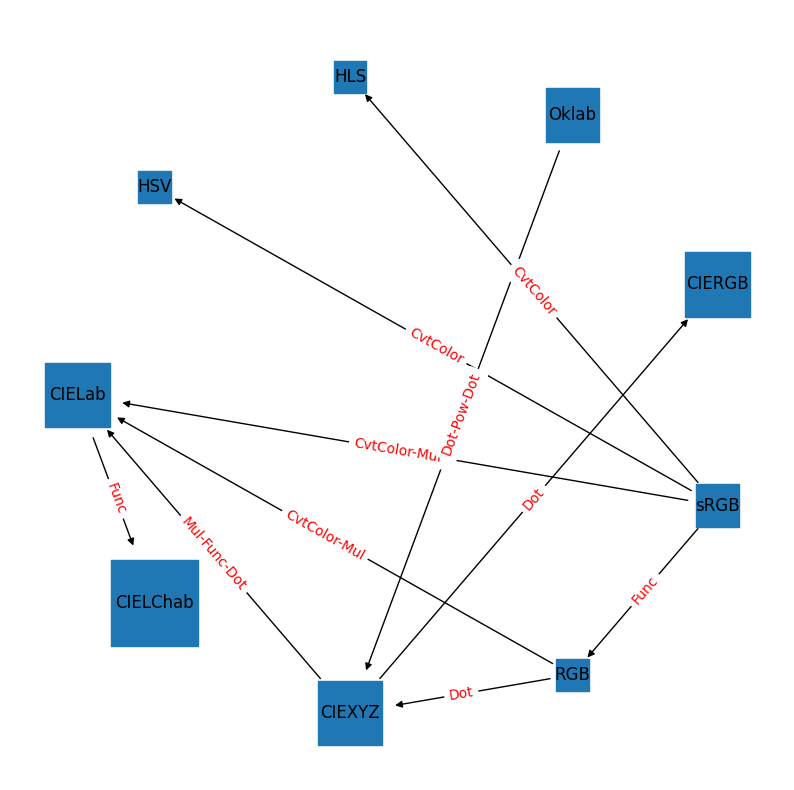

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from scipy.datasets import face

from glow import timer, time_this
from bipl.ops._color import _table, _paths, convert, list_colorspaces

print(list_colorspaces())

g = nx.DiGraph()
edge_names = {
    (k0, k1): '-'.join(v.children())
    for (k1, k0), v in _table.items()
    if k1 < k0
}
for (k0, k1), s in edge_names.items():
    g.add_edge(k0, k1, label=s)

fig, ax = plt.subplots(figsize=(10, 10))
# pos = nx.kamada_kawai_layout(g)
pos = nx.shell_layout(g)
nx.draw(
    g,
    pos,
    node_size=[60 * len(v) ** 2 for v in g.nodes()],
    node_shape='s',
    with_labels=True,
)
nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_names, font_color='red')
plt.show()

# 1  - Mul, Dot
# 2  - CvtColor
# 2  - Pow
# 10 - Func

In [2]:
import numpy as np
from bipl.ops._color import (
    _primaries,
    _primaries_xyz,
    _whites_xyz,
    _whites,
    _make_rgb,
    _table,
)

prims = dict(zip(_primaries, _primaries_xyz))
ws = dict(zip(_whites, _whites_xyz))

for m1, m2 in [
    (_make_rgb(prims['HDTV'], ws['D65']), _table['CIEXYZ', 'RGB'].m),
    (_make_rgb(prims['CIE RGB'], ws['E']), _table['CIEXYZ', 'CIERGB'].m),
]:
    print(np.abs(m1 - m2).max())
    print(m1.round(4))
    print(m2)

4.851818e-05
[[0.4124 0.3576 0.1804]
 [0.2126 0.7152 0.0722]
 [0.0193 0.1192 0.9503]]
[[0.4124564 0.3575761 0.1804375]
 [0.2126729 0.7151522 0.072175 ]
 [0.0193339 0.119192  0.9503041]]
0.00012981892
[[0.49   0.31   0.2   ]
 [0.1769 0.8124 0.0107]
 [0.     0.0099 0.9901]]
[[0.49    0.31    0.2    ]
 [0.17697 0.8124  0.01063]
 [0.      0.01    0.99   ]]


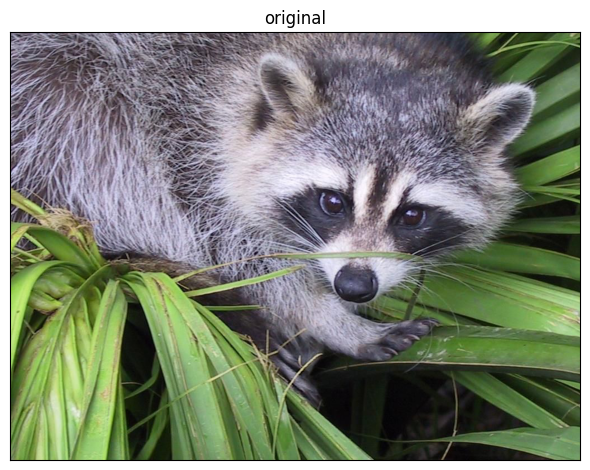

 _CvtColor(COLOR_RGB2HLS)
sRGB -> HLS done in 7.24ms
 _CvtColor(COLOR_HLS2RGB)
HLS -> sRGB done in 3.76ms

 _CvtColor(COLOR_RGB2HSV)
sRGB -> HSV done in 8.44ms
 _CvtColor(COLOR_HSV2RGB)
HSV -> sRGB done in 4.1ms

 _CvtColor(COLOR_RGB2Lab)
 _Mul()
sRGB -> CIELab done in 16.1ms
 _Mul()
 _CvtColor(COLOR_Lab2RGB)
CIELab -> sRGB done in 12.4ms

 _Func(<function _srgb_linearize at 0x0000024B7E1739C0>)
 _Dot(3, 3)
 _Pow
 _Dot(3, 3)
sRGB -> Oklab done in 52.6ms
 _Dot(3, 3)
 _Pow
 _Dot(3, 3)
 _Func(<function _srgb_gamma at 0x0000024B7E173A60>)
Oklab -> sRGB done in 41.3ms



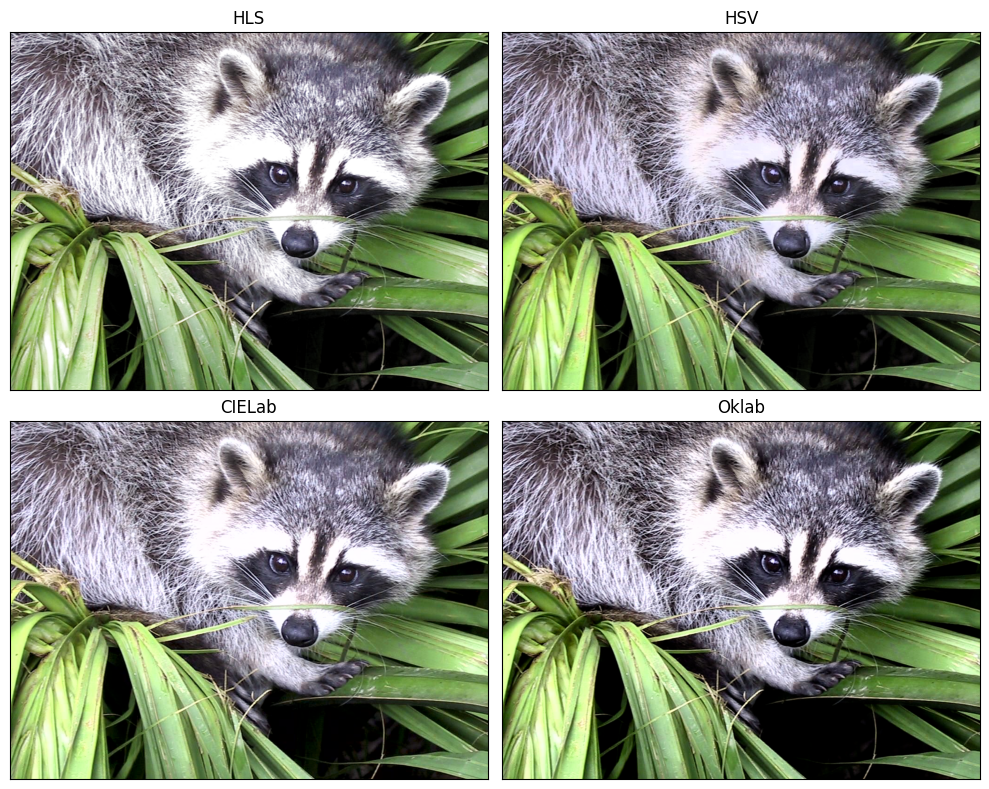

In [5]:
imf = face().astype('f4')
imf /= 255
imf.clip(0, 1, out=imf)

fig, ax = plt.subplots()
ax.imshow(imf)
ax.set(xticks=[], yticks=[], title='original')
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (cs, luma, chroma) in zip(
    axes.ravel(),
    (
        ('HLS', 1, 2),
        ('HSV', 2, 1),
        # ('CIEXYZ', slice(None), []),
        ('CIELab', 0, slice(1, None)),
        ('Oklab', 0, slice(1, None)),
    ),
):
    with timer(f'sRGB -> {cs}'):
        t = convert(imf.copy(), cs)

    lu, chro = t[..., luma], t[..., chroma]
    # lu = 0.5 * (lu + 1)  # 50% blend with pure white
    # lu *= 0.5  # 50% blend with pure black
    lu = (lu - np.percentile(lu, 5)) / (
        np.percentile(lu, [5, 95]) @ [-1, 1]
    )  # max contrast
    # lu *= 2  # 2x luminance
    # chro *= 2  # 2x saturation
    lu.clip(0, 1, out=t[..., luma])
    chro.clip(-1, 1, out=t[..., chroma])

    with timer(f'{cs} -> sRGB'):
        t = convert(t, 'sRGB', src=cs)

    ax.imshow(t.clip(0, 1))
    ax.set(xticks=[], yticks=[], title=cs)
    print()

fig.tight_layout()
plt.show()

for f in time_this.finalizers.values():
    f()